# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Muhammad Farid Wijdan | 5054251042 |

## Deskripsi Tugas
Di tugas ini saya membangun model Decision Tree Classifier untuk memprediksi kebangkrutan perusahaan.

Dataset: https://www.kaggle.com/datasets/abbas829/bankruptcy (data laporan keuangan perusahaan Taiwan tahun 1999-2009, targetnya kolom `Bankrupt?`)

Tujuannya biar paham praktik Decision Tree, khususnya:
1. Bedanya kriteria split Gini Impurity vs Entropy
2. Pengaruh `max_depth` ke overfitting


# 1. Persiapan Dataset dan Eksplorasi Awal


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
# load dataset
df = pd.read_csv('bankruptcy.csv')

# rapikan nama kolom (di file aslinya ada spasi di depan nama kolom)
df.columns = df.columns.str.strip()

print('Jumlah baris:', df.shape[0])
print('Jumlah kolom:', df.shape[1])
df.head()
df.info()
df.describe()
print('\nJumlah missing value per kolom:')
print(df.isnull().sum().sum())

Jumlah baris: 6819
Jumlah kolom: 96
<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                6819 non-null   int64  
 1   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2   ROA(A) before interest and % after tax                   6819 non-null   float64
 3   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4   Operating Gross Margin                                   6819 non-null   float64
 5   Realized Sales Gross Margin                              6819 non-null   float64
 6   Operating Profit Rate                                    6819 non-null   float64
 7   Pre-tax net Interest Rate                                6819 non-null   float64
 8   Aft

Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Persentase:
Bankrupt?
0    96.77
1     3.23
Name: proportion, dtype: float64


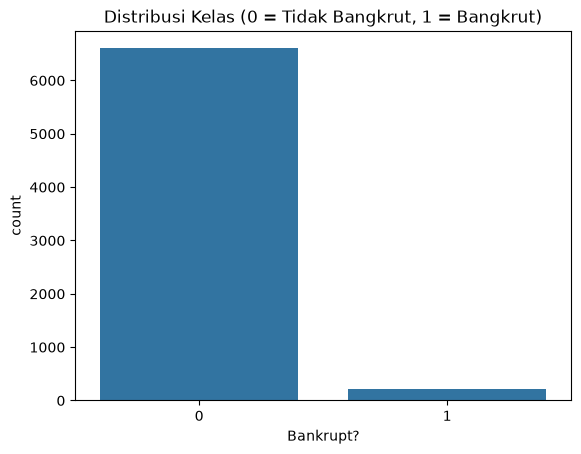

In [3]:
# distribusi kelas target
print(df['Bankrupt?'].value_counts())
print('\nPersentase:')
print((df['Bankrupt?'].value_counts(normalize=True) * 100).round(2))

sns.countplot(x='Bankrupt?', data=df)
plt.title('Distribusi Kelas (0 = Tidak Bangkrut, 1 = Bangkrut)')
plt.show()
# kelihatan datasetnya tidak seimbang (imbalanced), yang bangkrut cuma sedikit

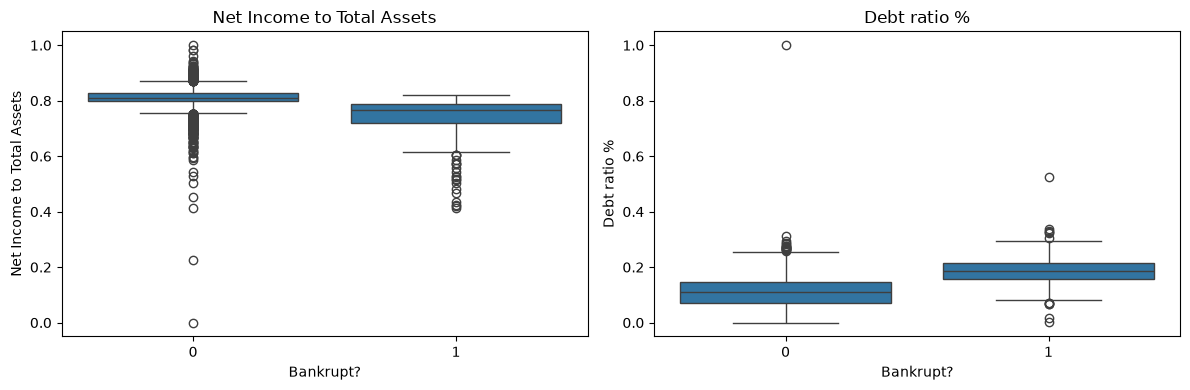

In [4]:
# lihat sebaran 2 fitur vs target, pakai boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x='Bankrupt?', y='Net Income to Total Assets', data=df, ax=axes[0])
axes[0].set_title('Net Income to Total Assets')
sns.boxplot(x='Bankrupt?', y='Debt ratio %', data=df, ax=axes[1])
axes[1].set_title('Debt ratio %')
plt.tight_layout()
plt.show()

## EDA tambahan: fitur apa yang paling berhubungan dengan kebangkrutan?


Net Income to Total Assets                                 0.315457
ROA(A) before interest and % after tax                     0.282941
ROA(B) before interest and depreciation after tax          0.273051
ROA(C) before interest and depreciation before interest    0.260807
Debt ratio %                                               0.250161
Net worth/Assets                                           0.250161
Persistent EPS in the Last Four Seasons                    0.219560
Retained Earnings to Total Assets                          0.217779
Net profit before tax/Paid-in capital                      0.207857
Per Share Net profit before tax (Yuan ¥)                   0.201395
dtype: float64


/Users/noir/Tugas Kuliah dan Belajar/Semester 3/ML/Tugas-Pratikum-ML/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/noir/Tugas Kuliah dan Belajar/Semester 3/ML/Tugas-Pratikum-ML/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


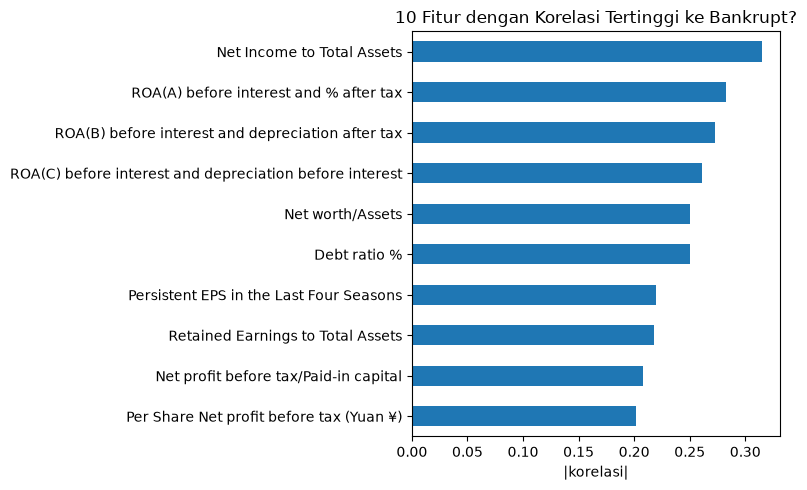

In [5]:
# hitung korelasi tiap fitur dengan target, ambil 10 terbesar
korelasi = df.drop(columns=['Bankrupt?']).apply(lambda c: c.corr(df['Bankrupt?']))
top10 = korelasi.abs().sort_values(ascending=False).head(10)
print(top10)

top10.sort_values().plot(kind='barh', figsize=(8, 5))
plt.title('10 Fitur dengan Korelasi Tertinggi ke Bankrupt?')
plt.xlabel('|korelasi|')
plt.tight_layout()
plt.show()

# 2. Preprocessing


In [6]:
# cek missing value
print('Total missing:', df.isnull().sum().sum())

# kalau ada yang kosong, isi pakai median (aman buat data numerik)
df = df.fillna(df.median(numeric_only=True))
print('Missing setelah dibersihkan:', df.isnull().sum().sum())

Total missing: 0
Missing setelah dibersihkan: 0


In [7]:
# cek tipe data tiap kolom, pastikan semua sudah angka
print(df.dtypes.value_counts())
objek = df.select_dtypes(include='object').columns.tolist()
print('Kolom kategorikal (teks):', objek)
# hasilnya kosong, jadi semua fitur sudah numerik dan tidak perlu encoding

float64    93
int64       3
Name: count, dtype: int64
Kolom kategorikal (teks): []


In [8]:
# pisahkan fitur (X) dan target (y)
X = df.drop(columns=['Bankrupt?'])
y = df['Bankrupt?']

# split 80:20, pakai stratify biar proporsi kelas bangkrut tetap sama
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

X_train: (5455, 95)
X_test : (1364, 95)


**Catatan:** Decision Tree tidak perlu feature scaling (StandardScaler/MinMaxScaler). Split-nya berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti KNN atau SVM. Jadi langsung lanjut ke training.


# 3. Eksperimen Model


## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity itu kriteria default di scikit-learn. Intinya mengukur seberapa sering sampel di suatu node bakal salah diklasifikasikan kalau labelnya ditebak acak.


In [9]:
# latih decision tree kriteria gini
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)
print('Selesai training. Kedalaman pohon:', dt_gini.get_depth())

Selesai training. Kedalaman pohon: 20


In [10]:
# prediksi ke test set
pred_gini = dt_gini.predict(X_test)
print('Akurasi (gini):', accuracy_score(y_test, pred_gini))

Akurasi (gini): 0.9611436950146628


## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) itu kriteria alternatif, mengukur tingkat ketidakpastian distribusi kelas di suatu node.


In [11]:
# latih decision tree kriteria entropy, hyperparameter lain disamakan biar adil
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)
print('Selesai training. Kedalaman pohon:', dt_entropy.get_depth())

Selesai training. Kedalaman pohon: 17


In [12]:
# prediksi ke test set
pred_entropy = dt_entropy.predict(X_test)
print('Akurasi (entropy):', accuracy_score(y_test, pred_entropy))

Akurasi (entropy): 0.9640762463343109


## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Kalau pohon dibiarkan tumbuh tanpa batas dia gampang overfitting (hafal data training). Di sini saya coba beberapa nilai `max_depth` pakai kriteria entropy.


In [13]:
# coba beberapa max_depth: 1, 2, 3, 5, 10, dan None (tanpa batas)
daftar_depth = [1, 2, 3, 5, 10, None]
model_depth = {}
for d in daftar_depth:
    m = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    model_depth[str(d)] = m
print('Selesai training', len(model_depth), 'model')

Selesai training 6 model


In [14]:
# hitung akurasi train dan test tiap max_depth
skor_train, skor_test = [], []
for d in daftar_depth:
    m = model_depth[str(d)]
    skor_train.append(m.score(X_train, y_train))
    skor_test.append(m.score(X_test, y_test))
    print(f'max_depth={d}: train={skor_train[-1]:.4f}, test={skor_test[-1]:.4f}')

max_depth=1: train=0.9677, test=0.9677
max_depth=2: train=0.9677, test=0.9677
max_depth=3: train=0.9683, test=0.9699
max_depth=5: train=0.9743, test=0.9663
max_depth=10: train=0.9930, test=0.9633
max_depth=None: train=1.0000, test=0.9641


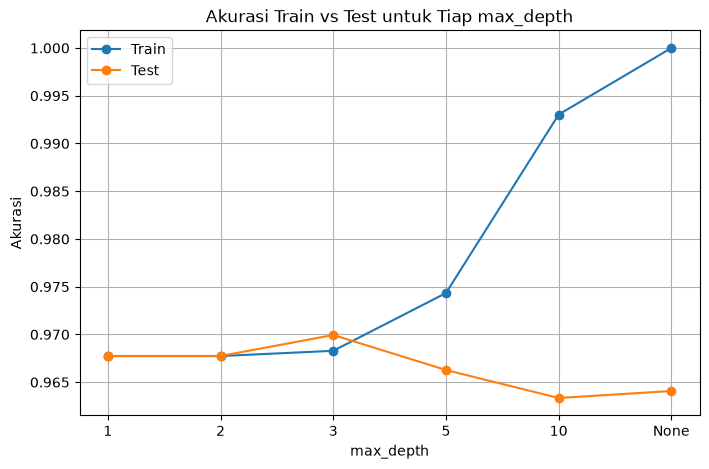

In [15]:
# plot akurasi training vs testing
plt.figure(figsize=(8, 5))
plt.plot([str(d) for d in daftar_depth], skor_train, marker='o', label='Train')
plt.plot([str(d) for d in daftar_depth], skor_test, marker='o', label='Test')
plt.xlabel('max_depth')
plt.ylabel('Akurasi')
plt.title('Akurasi Train vs Test untuk Tiap max_depth')
plt.legend()
plt.grid(True)
plt.show()
# akurasi train naik terus sampai 1.0, tapi akurasi test stagnan/menurun -> itu gejala overfitting

# 4. Evaluasi Model


In [16]:
# tabel perbandingan metrik gini vs entropy
hasil = pd.DataFrame({
    'Gini': [accuracy_score(y_test, pred_gini),
             precision_score(y_test, pred_gini, zero_division=0),
             recall_score(y_test, pred_gini, zero_division=0),
             f1_score(y_test, pred_gini, zero_division=0)],
    'Entropy': [accuracy_score(y_test, pred_entropy),
                precision_score(y_test, pred_entropy, zero_division=0),
                recall_score(y_test, pred_entropy, zero_division=0),
                f1_score(y_test, pred_entropy, zero_division=0)]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
print(hasil.round(4))

             Gini  Entropy
Accuracy   0.9611   0.9641
Precision  0.4000   0.4359
Recall     0.4091   0.3864
F1-Score   0.4045   0.4096


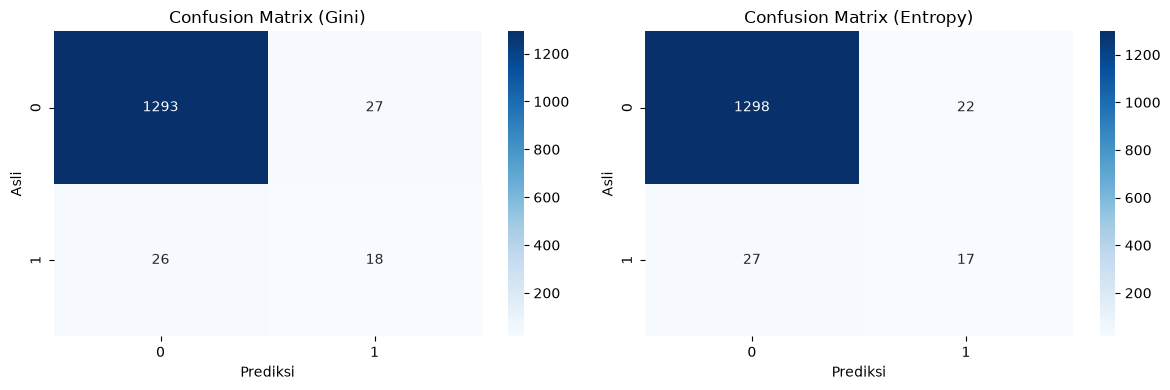

In [17]:
# confusion matrix gini vs entropy, dijejerkan biar gampang dibandingin
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pred, judul in zip(axes, [pred_gini, pred_entropy], ['Gini', 'Entropy']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix ({judul})')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Asli')
plt.tight_layout()
plt.show()

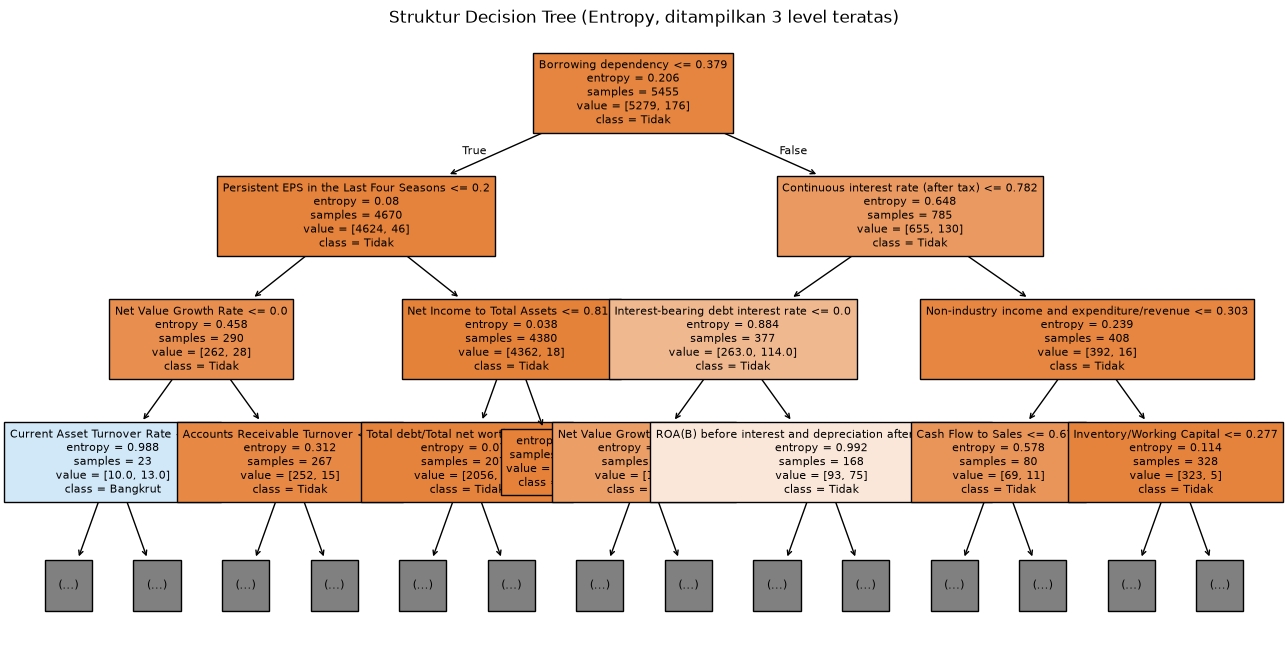

In [18]:
# visualisasi struktur pohon terbaik (entropy), dibatasi max_depth=3 biar gampang dibaca
plt.figure(figsize=(16, 8))
plot_tree(dt_entropy, max_depth=3, feature_names=X.columns.tolist(),
          class_names=['Tidak', 'Bangkrut'], filled=True, fontsize=8)
plt.title('Struktur Decision Tree (Entropy, ditampilkan 3 level teratas)')
plt.show()

Borrowing dependency                           0.222147
Continuous interest rate (after tax)           0.075791
Persistent EPS in the Last Four Seasons        0.063519
Net Value Growth Rate                          0.051659
Quick Ratio                                    0.029765
Operating Profit Growth Rate                   0.026979
Net Income to Total Assets                     0.024663
Interest-bearing debt interest rate            0.024218
Operating Expense Rate                         0.022477
Non-industry income and expenditure/revenue    0.018859
dtype: float64


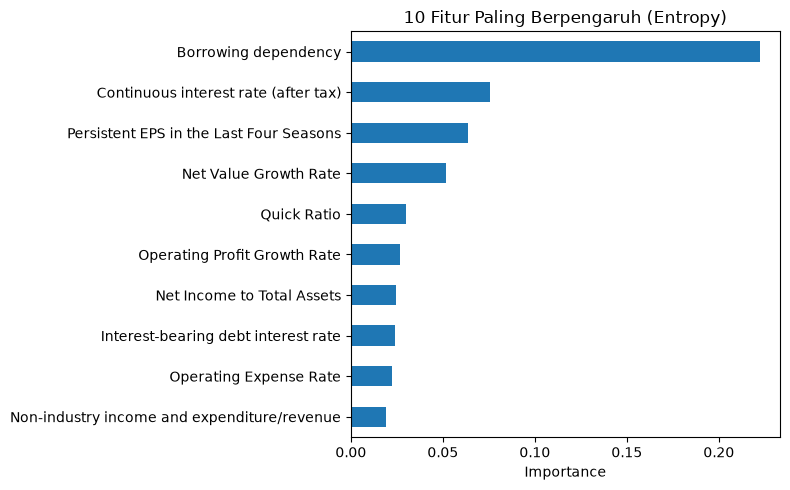

In [19]:
# feature importance dari model entropy, ambil 10 terbesar
penting = pd.Series(dt_entropy.feature_importances_, index=X.columns)
top = penting.sort_values(ascending=False).head(10)
print(top)

top.sort_values().plot(kind='barh', figsize=(8, 5))
plt.title('10 Fitur Paling Berpengaruh (Entropy)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# 5. Analisis

**Gini vs Entropy:** Hasilnya beda tipis dan tidak signifikan. Akurasi gini 0,9611 sedangkan entropy 0,9641. Precision entropy sedikit lebih bagus (0,4359 vs 0,4000) tapi recall-nya sedikit lebih rendah (0,3864 vs 0,4091), F1-nya praktis sama (0,4096 vs 0,4045). Menurut saya wajar karena cara kerja keduanya mirip, sama-sama mengukur ketidakmurnian node, jadi di dataset ini pohon yang terbentuk juga mirip (kedalaman 20 vs 17).

**Hal penting yang saya sadari:** dataset ini sangat imbalanced, yang bangkrut cuma 220 dari 6819 data (3,23%). Jadi kalau model asal menebak semua "tidak bangkrut" pun akurasinya sudah 96,77%. Artinya angka akurasi 96% itu menipu, yang lebih jujur dilihat itu precision/recall kelas bangkrut yang ternyata masih rendah (recall cuma ~0,39, jadi lebih dari setengah perusahaan yang bangkrut tidak ketangkap model).

**Eksperimen max_depth:** max_depth 1 dan 2 akurasinya 0,9677 sama persis dengan baseline, artinya pohonnya terlalu dangkal (underfit) sampai cuma menebak kelas mayoritas. Nilai paling bagus itu max_depth 3 dengan akurasi test 0,9699. Setelah itu gejala overfitting kelihatan jelas: akurasi train naik terus (0,9930 di depth 10, bahkan 1,0000 kalau tanpa batas) sementara akurasi test malah stagnan di sekitar 0,963-0,966. Cirinya persis seperti teori: garis train terus naik, garis test datar/menurun.

**Fitur paling berpengaruh:** menurut feature importance model, `Borrowing dependency` (ketergantungan pinjaman) paling dominan dengan skor 0,222, jauh di atas fitur lainnya. Sementara kalau dilihat dari korelasi, `Net Income to Total Assets` yang tertinggi (0,315), diikuti rasio ROA dan `Debt ratio %`. Keduanya masuk akal: perusahaan yang labanya jelek dan terlalu bergantung ke pinjaman memang paling rawan bangkrut, dan ini juga kelihatan dari boxplot di EDA.


# 6. Kesimpulan dan Saran

**Kesimpulan:** Model Decision Tree bisa memprediksi kebangkrutan dengan akurasi sekitar 96%, tapi karena datanya imbalanced angka itu tidak boleh ditelan mentah-mentah, kemampuan menangkap kelas bangkrutnya (recall ~0,39) masih kurang. Kriteria entropy sedikit lebih baik dari gini tapi bedanya kecil. Regularisasi `max_depth` terbukti penting: max_depth 3 jadi titik terbaik, pohon yang terlalu dalam jelas overfitting (train 100%, test malah turun).

**Saran:** (1) menangani imbalance-nya dulu, misalnya pakai `class_weight='balanced'` atau SMOTE, lalu evaluasi pakai F1/ROC-AUC bukan akurasi; (2) coba pruning dengan `ccp_alpha` atau atur `min_samples_leaf` biar pohon tidak terlalu rimbun; (3) bandingkan dengan model lain seperti Random Forest atau Logistic Regression buat pembanding.
